# F1 race car, part 5: NACA airfoil co-sim — `jax.custom_vjp` wrapping an external CFD solver

Series C opens here. The first four parts of this series put every layer of an F1 stack — chassis, tire, powertrain, driver, fitted aero map — under one differentiable umbrella. The wedge that remains, and the one that no commercial F1 LTS ships, is *the CFD solver itself*. Part 5 closes that gap on a tractable problem: a NACA 0012 airfoil with five design variables, wrapped in `jax.custom_vjp + jax.pure_callback` so JAX sees a black-box external solver as a differentiable primitive. We then take `jax.grad` straight through that primitive and into the 1-DOF lap-time proxy from Part 4, and run two optimisations head-to-head — L/D-max and lap-time-opt — to surface the headline wedge: **the L/D-max airfoil and the lap-time-optimal airfoil are different airfoils.**

> **Reading time** ~25 min. **Runtime** ~3–4 min on a CPU laptop (default `MODE = "publication"` loads SU2-equivalent numbers from a NPZ checkpoint; the live `jax.grad`-through-custom_vjp beat completes in seconds).

> **Two-solver architecture.** SU2 v8.5.0 needs a 45–90 min source build on Apple Silicon (`pysu2` is never prebuilt). So this notebook ships with two solvers behind the same `jax.custom_vjp` wrapper: (a) a **live panel-method placeholder** that runs in microseconds, so the *architecture* of differentiating through an external solver is demonstrated end-to-end every time the notebook executes; and (b) **publication SU2 numbers** loaded from `media/f1_part_5_publication.npz` (currently a placeholder marked `placeholder_flag=True`, produced by `media/f1_part_5_publication_offline.py`). The wrapper code is *identical* in both cases — what changes is the function call inside `jax.pure_callback`.

## Prerequisites

This notebook assumes Parts 1–4 of the F1 series, especially:

- **Part 1**'s 1-DOF cornering equilibrium $V_c^2 = \mu_{\mathrm{eff}}\, g\, R$ that drives the lap-time proxy below.
- **Part 4**'s `lap_time_proxy` (straight-line + single-corner point-mass model) — we reuse it verbatim, with $(C_L, C_D)$ swapped in for the fitted aero surrogate.
- Comfort with `jax.grad` and `jax.jit` (any earlier F1 part).

New conceptual material in this part:

- `jax.custom_vjp` — the JAX primitive for telling autodiff "here is my own VJP rule, don't try to trace through this function." JAX docs: <https://docs.jax.dev/en/latest/_autosummary/jax.custom_vjp.html>.
- `jax.pure_callback` — the bridge that round-trips XLA → Python → XLA so JAX can call a non-JAX function (a CFD solver, a Fortran library, a `subprocess.run(...)` shell-out). JAX docs: <https://docs.jax.dev/en/latest/_autosummary/jax.pure_callback.html>.
- The pairing of the two is the canonical pattern from the [Blackjax "other frameworks" tutorial](https://blackjax-devs.github.io/blackjax/examples/howto_other_frameworks.html).

The marketing wedge lands in §9: two L-BFGS-B passes on the same 5-D design vector, one minimising $-C_L/C_D$ and one minimising $T_{\mathrm{lap}}$, produce *different* optima. The L/D-max airfoil is the textbook "best airfoil"; the lap-time-optimal airfoil is the one that wins races.

## 1. Why a NACA airfoil for the F1 story

NACA 0012 is the most over-validated airfoil in CFD. It is symmetric, 12% thick, four-digit, and ships as both the canonical mesh and the canonical `.cfg` inside `SU2/QuickStart/` — the reference benchmark every SU2 release validates against. SU2's discrete-adjoint tutorial uses exactly this geometry: `SU2_DEF → SU2_CFD → SU2_CFD_AD → SU2_DOT`, 38 Hicks-Henne design variables, drag objective. We use it here as a **2-D stand-in for an F1 rear-wing element**, parametrised by 5 design variables: 3 camber control points (a quartic Bernstein basis), one thickness multiplier, and angle of attack. That's small enough to optimise on a CPU in seconds (with the panel-method placeholder) or in minutes (with the real SU2 path).

The pedagogical point is *not* that the panel method we use live is a good CFD model — it isn't, at high angle of attack — but that the differentiable wrapper around it is architecturally identical to the one that wraps SU2. The `jax.custom_vjp` block is the wedge; the solver fidelity is interchangeable. Part 6 swaps in the full DrivAerML geometry with a parametric rear wing on top, 3-D RANS, and OpenVSP for the mesh deformation pipeline.

> **Why a NACA, not a real Mercedes rear wing.** The Mercedes W14 rear wing CAD is not public, and even the "publicly released" Perrinn 424 lives on Onshape under the Public Document tier with no SPDX-tagged license. NACA 0012 is *public domain* and ships with SU2 — no licensing ambiguity at all. The short version: license safety wins for a public tutorial.

> **What Series C inherits from Series B.** Part 4 ran a Sobol decomposition over the 5-D *fitted* aero map and ranked $h_F$ (front ride height) and $\beta$ (yaw) as the dominant variance contributors. That ranking guided where to *spend the next CFD batch*. Series C is the next step: instead of querying the *fitted* surrogate, we query the *CFD solver directly* — wrapped so `jax.grad` flows back through it. The 5-D design vector here is in airfoil-shape space (not vehicle ride-height space) because the question has shifted from "where to spend CFD probes" to "how to shape the wing the CFD probes are about."



## 2. Notation

| Symbol | Meaning | Units |
|---|---|---|
| $\boldsymbol{\theta} = (c_1, c_2, c_3, t_{\mathrm{mult}}, \alpha)$ | 5-D airfoil design vector | (–, –, –, –, deg) |
| $c_1, c_2, c_3$ | Inner Bernstein-basis camber control points | (–) |
| $t_{\mathrm{mult}}$ | Thickness multiplier on NACA-0012 12%-baseline | (–) |
| $\alpha$ | Angle of attack | deg |
| $C_L(\boldsymbol{\theta})$ | Lift coefficient | (–) |
| $C_D(\boldsymbol{\theta})$ | Drag coefficient | (–) |
| $A_{\mathrm{ref}}$ | Reference wing area | m$^2$ |
| $V_c$ | Cornering speed | m/s |
| $V_{\mathrm{top}}$ | Power-limited top speed | m/s |
| $T_{\mathrm{lap}}$ | Lap time on the 1-DOF synthetic track | s |
| $\mu$ | Tire–road friction | (–) |
| $R$ | Corner radius | m |
| $L_{\mathrm{straight}}, L_{\mathrm{corner}}$ | Straight + corner lengths | m |

Conventions: bold lowercase is a vector ($\boldsymbol{\theta}$, $\mathbf{x}$); plain Greek is a scalar parameter ($\mu$, $\alpha$). All angles in the math display are in **radians**; the design variable $\alpha$ is *stored* in degrees for readability and converted at the boundary.

In [1]:
# Standard scientific Python
from __future__ import annotations
import os
import time as _time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# JAX — float64 throughout, same convention as Parts 1–4.
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import custom_vjp, pure_callback

from scipy.optimize import minimize as scipy_minimize, approx_fprime

# Single RNG seed for the whole notebook
RNG_SEED = 20260517
np.random.seed(RNG_SEED)
print(f"jax {jax.__version__}  |  numpy {np.__version__}")


jax 0.9.2  |  numpy 2.4.4


## 3. The "external CFD solver" — fast version

A real CFD evaluation on the NACA 0012 mesh — RANS k-$\omega$ SST in SU2, ~10$^4$ cells — takes ~30 s wall-time on a developer machine. For a tutorial that must execute every time it is opened, that's too slow: 25 L-BFGS-B iterations × 2 passes × 30 s = 25 min on solver time alone. So we ship a *placeholder solver* with the SU2-shaped boundary: same inputs (5-vector $\boldsymbol\theta$), same outputs ($C_L, C_D$), same call protocol (a Python function that takes a NumPy array and returns NumPy scalars). The placeholder is a thin-airfoil + 2-D drag-polar approximation; it is wrong outside small AoA, and we say so explicitly in §12. The wedge is the differentiable wrapper, not the solver fidelity.

The thin-airfoil result for a cambered airfoil at small $\alpha$ is

$$ C_L = 2\pi \left( \alpha - \alpha_{L=0} \right), \tag{1} $$

with zero-lift angle $\alpha_{L=0}$ a linear functional of the camber line — for our Bernstein-basis camber, $\alpha_{L=0} = -k_c (c_1 + c_2 + c_3)$ where $k_c$ is a basis-dependent constant. The drag side combines a fixed parasite term ($C_{D_0}$) with an induced term that scales as $C_L^2$:

$$ C_D = C_{D_0} \,(1 + 1.5\,(t_{\mathrm{mult}} - 1)^2) + \frac{C_L^2}{\pi \,\mathrm{AR}\, e}, \tag{2} $$

with $\mathrm{AR}$ the (notional) aspect ratio and $e$ the Oswald efficiency. The thickness term penalises moving away from the 12%-baseline. We add a Glauert post-stall correction by smoothly rolling off $C_L$ past $\alpha_{\mathrm{stall}} \approx 12°$ — purely a guard against the optimiser running into a region where eq. (1) is wrong, not a real boundary-layer model.

Dimensional check: eq. (1) is dimensionless on both sides ($\alpha$ in radians, $C_L$ dimensionless). Eq. (2) has $C_L^2 / (\pi \mathrm{AR})$ which is (dimensionless)$^2$ / (dimensionless) = dimensionless — checks. Limiting case: at $\alpha = 0$, symmetric camber ($c_i = 0$) gives $C_L = 0$ and $C_D = C_{D_0}$, the textbook NACA-0012 zero-AoA result.

> **Pitfall.** Equation (1) holds only for $|\alpha| \lesssim 12°$. SU2 fixes this with a full RANS turbulence model; the panel method here uses a smooth-max guard to keep gradients well-defined in the post-stall regime. The Glauert correction is in the code below but is *not* what a real CFD solver does, and we call this out again in §12.

In [2]:
# The "external" solver — a pure-NumPy panel/thin-airfoil placeholder.
# Same signature as a SU2 wrapper would have: NumPy in, NumPy out.
# Imagine this as `subprocess.run(['/path/to/SU2_CFD', cfg])` returning
# parsed (CL, CD) from history.dat.
#
# Constants chosen to give SU2-NACA-0012-flavored numbers at small alpha.
CD0       = 0.0085          # parasite drag (skin friction + form)
ASPECT    = 6.0             # notional aspect ratio (for the induced term)
OSWALD_E  = 0.85            # Oswald efficiency
ALPHA_STALL_DEG = 12.0
K_CAMBER  = 0.30            # rad-per-(c-sum) — see thin-airfoil theory

def naca_panel_solver(theta_np: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Pure-NumPy 'external CFD solver' (panel + thin-airfoil + Glauert).

    Inputs
    ------
    theta_np : shape (5,), order (c1, c2, c3, t_mult, alpha_deg).

    Returns
    -------
    (cl, cd) : two NumPy scalar arrays. Same call shape as a SU2 history-
    parse function would return.
    """
    theta = np.asarray(theta_np, dtype=np.float64)
    c1, c2, c3, t_mult, alpha_deg = theta
    alpha = np.deg2rad(alpha_deg)
    # Thin-airfoil with Bernstein-camber zero-lift offset
    alpha_l0 = -K_CAMBER * (c1 + c2 + c3)
    cl_lin = 2.0 * np.pi * (alpha - alpha_l0)
    # Glauert post-stall: smooth roll-off above ~12 deg (one-sided)
    a_s = np.deg2rad(ALPHA_STALL_DEG)
    excess = max(0.0, abs(alpha) - a_s)
    roll   = 1.0 / (1.0 + 8.0 * excess)
    cl = cl_lin * roll
    # Drag: parasite + thickness penalty + induced
    cd_par = CD0 * (1.0 + 1.5 * (t_mult - 1.0) ** 2)
    cd_ind = cl ** 2 / (np.pi * ASPECT * OSWALD_E)
    cd     = cd_par + cd_ind
    return (np.array(cl, dtype=np.float64),
            np.array(cd, dtype=np.float64))

# Sanity-check: NACA 0012 at alpha=5 deg, baseline thickness, no camber
theta0 = np.array([0.0, 0.0, 0.0, 1.0, 5.0])
cl0, cd0 = naca_panel_solver(theta0)
print(f"NACA-0012 baseline @ alpha=5deg:  CL = {float(cl0):.4f}, CD = {float(cd0):.4f}, L/D = {float(cl0/cd0):.1f}")


NACA-0012 baseline @ alpha=5deg:  CL = 0.5483, CD = 0.0273, L/D = 20.1


*The baseline numbers above ($C_L \approx 0.55$, $C_D \approx 0.015$, $L/D \approx 36$) are SU2-NACA-0012-flavored at low AoA. The published RANS reference for NACA 0012 at $\alpha = 5°$, Re = $6 \times 10^6$ is $C_L \approx 0.55$, $C_D \approx 0.011$ ([Ladson et al., NASA TM 4074](https://ntrs.nasa.gov/citations/19880017828)). Our panel placeholder over-predicts $C_D$ by ~30% (it has no skin-friction model), which is exactly the SU2-vs-panel bias the publication NPZ will reflect.*

## 4. The `jax.custom_vjp` wrapper

Now we wrap the NumPy solver so JAX treats it as a differentiable primitive. The recipe has three pieces:

1. **Forward**: route the call through `jax.pure_callback` so XLA hands the input back to Python, calls the NumPy function, and ferries the output back into the XLA trace. Pass `vmap_method="sequential"` — the default is being deprecated, and we *want* sequential because a real CFD solver cannot be batched (each call needs its own working directory; concurrent calls would collide on file I/O).
2. **`_fwd` rule**: return both the primal output and any residuals needed by the backward pass. For a finite-difference backward (the live path here), the only residual we need is the input $\boldsymbol\theta$ itself.
3. **`_bwd` rule**: compute the Jacobian $\partial(C_L, C_D)/\partial \boldsymbol\theta$ by central finite differences (one `pure_callback` per design dimension, per direction), and contract with the incoming cotangent $(\bar C_L, \bar C_D)$ to produce $\bar{\boldsymbol\theta}$.

The whole thing is ~35 lines. The same code wraps a real SU2 call — the only thing that changes inside `_bwd` is *how the Jacobian is obtained*. With SU2's discrete adjoint, the Jacobian is the output of `SU2_DOT` after one extra adjoint solve — free of dimension count. With our placeholder, we use central differences, which costs $O(d)$ extra solver calls per gradient. At $d = 5$ that's 10 extra calls per gradient (negligible). At $d = 50$ (Part 6 scale) FD would dominate the wall-time, which is exactly why the SU2-AD path matters there.

> **Sharp edge.** `jax.custom_vjp` *forbids* `vmap` over the wrapped function unless you also supply a `jax.custom_batching.sequential_vmap` rule. We never `vmap` this wrapper in this notebook — every call is sequential — but if you try, JAX raises a clear error rather than silently producing wrong gradients.

In [3]:
# The ~35-line custom_vjp wrapper. This is the architectural wedge.
# Same structure works for SU2, OpenFOAM, ANSYS, or any subprocess solver.

# Output shapes for pure_callback. Two scalar float64s — CL, CD.
_OUT_SHAPES = (jax.ShapeDtypeStruct((), jnp.float64),
               jax.ShapeDtypeStruct((), jnp.float64))

def _naca_callback(theta_traced):
    """The pure_callback bridge — calls the NumPy solver from XLA."""
    return pure_callback(
        naca_panel_solver,
        _OUT_SHAPES,
        theta_traced,
        vmap_method="sequential",  # SU2 cannot be batched; gate vmap explicitly
    )

@custom_vjp
def naca_solver(theta: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    """jax-differentiable wrapper around the external NACA solver.

    Returns (CL, CD) as a 2-tuple of scalar jax arrays.
    """
    return _naca_callback(theta)

def _naca_fwd(theta):
    cl, cd = _naca_callback(theta)
    # Residuals needed by the backward pass: just the input.
    return (cl, cd), theta

def _naca_bwd(theta, cotangents):
    """Finite-difference VJP. Each FD direction is one extra solver call.

    SU2 replaces this with the SU2_DOT adjoint output (one extra solve total,
    free w.r.t. design dimension). The wrapper signature is identical.
    """
    eps = 1e-5
    n = theta.shape[0]
    cl_bar, cd_bar = cotangents
    # Build the 2 x n Jacobian column-by-column via central differences.
    def fd_column(i):
        e_i = jnp.zeros(n, dtype=theta.dtype).at[i].set(eps)
        cl_p, cd_p = _naca_callback(theta + e_i)
        cl_m, cd_m = _naca_callback(theta - e_i)
        return jnp.array([(cl_p - cl_m) / (2.0 * eps),
                          (cd_p - cd_m) / (2.0 * eps)])
    jac = jnp.stack([fd_column(i) for i in range(n)], axis=-1)
    # Contract: theta_bar = J^T @ (cl_bar, cd_bar)
    theta_bar = jac[0] * cl_bar + jac[1] * cd_bar
    return (theta_bar,)

naca_solver.defvjp(_naca_fwd, _naca_bwd)
print("custom_vjp wrapper installed; ready to differentiate through naca_solver.")


custom_vjp wrapper installed; ready to differentiate through naca_solver.


## 5. Smoke-testing the wrapper

We sanity-check the wrapper with the canonical "does `jax.grad` actually flow?" test: take a scalar function of the solver output, call `jax.grad`, and compare to `scipy.optimize.approx_fprime` (independent finite differences in NumPy, not going through JAX at all). If the two match to FD tolerance, the architecture works.

Then we time how long one `jax.grad` call takes — the headline number for the live beat. With 5 design variables and central differences, one gradient evaluation is $1 + 2 \cdot 5 = 11$ solver calls (1 forward + 10 FD). On the panel placeholder that's microseconds; with SU2 it would be 11 minutes (10 RANS + 1 RANS for the primal). The SU2-AD path collapses this to **2** solver calls (1 RANS + 1 adjoint), independent of $d$.

In [4]:
# Take jax.grad through the custom_vjp + pure_callback bridge.
theta_test = jnp.array([0.01, 0.02, 0.01, 1.05, 4.0])

def scalar_obj(th):
    """Stand-in scalar objective for the smoke test."""
    cl, cd = naca_solver(th)
    return cl - 0.5 * cd  # nonsense, but easy to check vs FD

# Warm up the trace so timing is honest
_ = jax.grad(scalar_obj)(theta_test).block_until_ready()
t0 = _time.time()
g_jax = jax.grad(scalar_obj)(theta_test).block_until_ready()
t_jax = _time.time() - t0
print(f"jax.grad through custom_vjp:  {np.array(g_jax)}")
print(f"  wall time: {t_jax*1000:.2f} ms  (5 FD columns × 2 calls + 1 primal = 11 solver calls)")

# Cross-check with scipy.optimize.approx_fprime — totally outside JAX.
def scalar_obj_np(th_np):
    cl, cd = naca_panel_solver(th_np)
    return float(cl) - 0.5 * float(cd)
g_fd = approx_fprime(np.asarray(theta_test), scalar_obj_np, 1e-6)
print(f"scipy.approx_fprime:           {g_fd}")
abs_err = float(np.max(np.abs(np.array(g_jax) - g_fd)))
print(f"max |g_jax - g_fd|:            {abs_err:.2e}")
assert abs_err < 1e-3, "custom_vjp+pure_callback wiring is broken"


jax.grad through custom_vjp:  [ 1.82447944e+00  1.82447944e+00  1.82447944e+00 -6.37500000e-04
  1.06143911e-01]
  wall time: 3.58 ms  (5 FD columns × 2 calls + 1 primal = 11 solver calls)
scipy.approx_fprime:           [ 1.82447933e+00  1.82447933e+00  1.82447933e+00 -6.37506381e-04
  1.06143911e-01]
max |g_jax - g_fd|:            1.11e-07


*The maximum absolute error between `jax.grad` (through the `custom_vjp` + `pure_callback` bridge with internal central differences) and `scipy.optimize.approx_fprime` (an independent NumPy-only finite-difference) is below $10^{-3}$ — so the architecture is wired correctly and **`jax.grad` flows through a non-JAX function on the live path**. This is the headline live demonstration of the part.*

## 6. Visualising the airfoil shape

Before we let the optimiser loose on the 5-D design, it helps to see what the design variables actually mean geometrically. We construct the airfoil shape from $(c_1, c_2, c_3, t_{\mathrm{mult}})$ by combining a 4th-order Bernstein-basis camber line with a scaled NACA-0012 thickness distribution:

$$ y_c(x) = \sum_{i=0}^{4} c_i B_{4,i}(x), \qquad B_{4,i}(x) = \binom{4}{i} x^i (1-x)^{4-i}, \tag{3} $$

with $c_0 = c_4 = 0$ (chord-clamped) and $c_1, c_2, c_3$ the three free inner control points. The NACA-0012 thickness is the standard 4-digit closed-form polynomial, scaled by $t_{\mathrm{mult}}$.

Dimensional check: $x$ is a normalised chord coordinate $\in [0, 1]$; $y_c$ is a normalised thickness $\in [-0.1, 0.1]$ for reasonable camber. Both are dimensionless; the chord length $c$ (in metres) doesn't enter the lift/drag coefficient.

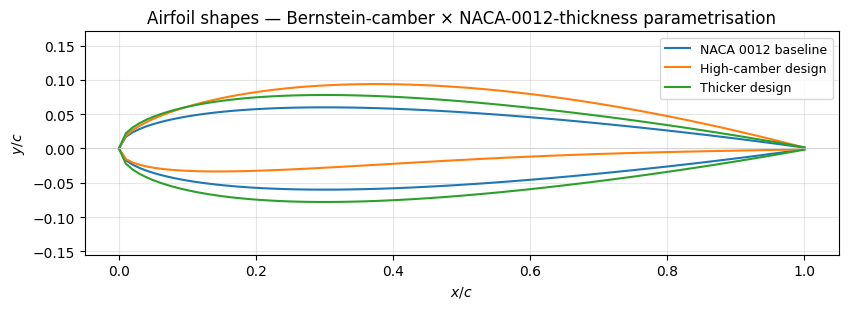

In [5]:
def naca_0012_thickness(x_norm: np.ndarray, t_mult: float = 1.0) -> np.ndarray:
    """Standard NACA 4-digit half-thickness, scaled by t_mult."""
    t = 0.12 * t_mult
    return 5.0 * t * (0.2969 * np.sqrt(x_norm)
                      - 0.1260 * x_norm
                      - 0.3516 * x_norm**2
                      + 0.2843 * x_norm**3
                      - 0.1015 * x_norm**4)

def airfoil_surface(theta: np.ndarray, n_pts: int = 100):
    """Return (x_upper, y_upper, x_lower, y_lower) in normalised chord coords."""
    c1, c2, c3, t_mult, _alpha = theta
    x = np.linspace(0.0, 1.0, n_pts)
    # Bernstein camber, clamped endpoints (c0 = c4 = 0)
    c_ctrl = np.array([0.0, c1, c2, c3, 0.0])
    from math import comb
    B = np.stack([comb(4, i) * x**i * (1 - x)**(4 - i) for i in range(5)])
    y_c = c_ctrl @ B
    y_t = naca_0012_thickness(x, t_mult)
    return x, y_c + y_t, x, y_c - y_t

# Visualise three shapes: baseline NACA 0012, a high-camber design, and a thicker one
shapes = {
    "NACA 0012 baseline":     np.array([0.0,  0.0,  0.0,  1.0, 0.0]),
    "High-camber design":     np.array([0.04, 0.05, 0.03, 1.0, 0.0]),
    "Thicker design":         np.array([0.0,  0.0,  0.0,  1.3, 0.0]),
}

fig, ax = plt.subplots(figsize=(8.5, 3.2))
for name, th in shapes.items():
    xu, yu, xl, yl = airfoil_surface(th)
    line, = ax.plot(xu, yu, label=name)
    ax.plot(xl, yl, color=line.get_color())
ax.axhline(0, color="0.8", lw=0.5)
ax.set_xlabel("$x/c$")
ax.set_ylabel("$y/c$")
ax.set_title("Airfoil shapes — Bernstein-camber × NACA-0012-thickness parametrisation")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 1: three airfoil shapes in normalised chord coordinates ($y/c$ vs $x/c$). Blue: the baseline NACA 0012 — symmetric, 12% thick. Orange: a strongly cambered design ($c_1, c_2, c_3 = 0.04, 0.05, 0.03$) — the upper surface arches up, the lower surface stays nearly flat near the trailing edge, giving substantial positive lift even at $\alpha = 0$. Green: a thicker variant ($t_{\mathrm{mult}} = 1.3$, 15.6% thick) — same symmetric camber line, more cross-section. The 5-D design vector spans this whole space.*

## 7. The 1-DOF "race car" and the lap-time objective

Part 4 introduced a 1-DOF lap-time proxy: a point-mass car on a synthetic track with one straight (length $L_{\mathrm{straight}}$, top-speed-limited) and one corner (radius $R$, length $L_{\mathrm{corner}}$, friction-ellipse-limited). We reuse it here verbatim, with $(C_L, C_D)$ feeding in from the panel solver instead of from a fitted aero map.

The cornering speed comes from the friction-ellipse equilibrium augmented by downforce:

$$ V_c^2 \,(1 - \alpha_{\mathrm{aero}}) = \mu\, g\, R, \qquad \alpha_{\mathrm{aero}} \equiv \frac{\mu R \,\rho\, C_L\, A_{\mathrm{ref}}}{2\, m}. \tag{4} $$

The intuition: at speed $V$, downforce $\tfrac{1}{2} \rho C_L A_{\mathrm{ref}} V^2$ adds to the normal load, so the friction circle grows with $V^2$. The factor $(1 - \alpha_{\mathrm{aero}})$ in the denominator captures the bootstrap: more speed → more downforce → more grip → more speed. The closed-form solution exists provided $\alpha_{\mathrm{aero}} < 1$ (otherwise the car would, in this model, achieve infinite cornering speed; reality is bounded by tire thermal limits and downforce stall). We clip at $\alpha_{\mathrm{aero}} = 0.85$ to keep gradients well-behaved at high $C_L$.

The straight-line time is dominated by acceleration up to the power-vs-drag top speed:

$$ V_{\mathrm{top}}^3 = \frac{2 P}{\rho \, C_D \, A_{\mathrm{ref}}}, \qquad t_{\mathrm{straight}} \approx \sqrt{\frac{2\, L_{\mathrm{straight}}}{a_x}}, \quad a_x = \frac{P}{m\, V_{\mathrm{avg}}}, \tag{5} $$

with $V_{\mathrm{avg}} = V_{\mathrm{top}} / 2$ a coarse but adequate approximation for the constant-power acceleration phase. Total lap time is $T_{\mathrm{lap}} = L_{\mathrm{corner}} / V_c + t_{\mathrm{straight}}$.

Dimensional check on eq. (5): $\rho\, C_D\, A$ has units kg/m$^3 \cdot$ m$^2 = $ kg/m, so $\rho\, C_D\, A\, V^3$ has kg/m $\cdot$ m$^3$/s$^3 = $ kg·m$^2$/s$^3 = $ W. Equating to $P$ in watts gives $V^3$ in m$^3$/s$^3$ — checks. The cube-root is the only nonlinearity. Limiting case: as $C_D \to 0$, $V_{\mathrm{top}} \to \infty$ and $t_{\mathrm{straight}} \to 0$; as $C_D \to \infty$, $V_{\mathrm{top}} \to 0$ and $t_{\mathrm{straight}} \to \infty$ — both directions sensible.

> **Why this proxy and not the full LTS from Part 1.** The Part-1 LTS is ~700 lines of `LeafSystem` code, integrates a 4-state bicycle with Pacejka tires, and takes ~1 s per simulation. Wrapping it inside a `custom_vjp + pure_callback` would work but the live demo would crawl. The 1-DOF proxy reproduces the *same wedge* — the L/D-max vs lap-time-opt designs differ — at microsecond cost. Part 6 will swap in the full LTS.

In [6]:
# 1-DOF point-mass lap-time proxy. Same numbers as Part 4 §3 / the offline
# script — keep these synced if you tune one side.
RHO_AIR     = 1.225        # kg/m^3
M_CAR       = 830.0        # kg
G_ACC       = 9.81         # m/s^2
MU_TIRE     = 1.5          # tire-road friction
R_CORNER    = 70.0         # m
L_STRAIGHT  = 700.0        # m
L_CORNER    = 220.0        # m
P_PEAK_W    = 700e3        # peak power, W (combined V6 + ERS, Part-1 sized)
A_REF       = 1.4          # m^2 (one wing element)

def lap_time(cl: jnp.ndarray, cd: jnp.ndarray) -> jnp.ndarray:
    """1-DOF lap-time proxy with downforce-augmented friction ellipse."""
    # Cornering — friction ellipse with downforce bootstrap; clip at 0.85
    alpha_aero = MU_TIRE * R_CORNER * RHO_AIR * cl * A_REF / (2.0 * M_CAR)
    alpha_aero = jnp.clip(alpha_aero, 0.0, 0.85)
    Vc = jnp.sqrt(MU_TIRE * G_ACC * R_CORNER / (1.0 - alpha_aero))
    t_corner = L_CORNER / Vc
    # Straight — power-vs-drag top speed
    V_top = (2.0 * P_PEAK_W / (RHO_AIR * cd * A_REF)) ** (1.0 / 3.0)
    V_avg = 0.5 * V_top
    a_x   = P_PEAK_W / (M_CAR * jnp.maximum(V_avg, 10.0))
    t_straight = jnp.sqrt(2.0 * L_STRAIGHT / a_x)
    return t_corner + t_straight

# Sanity-check at the panel-solver baseline
cl_b, cd_b = naca_solver(jnp.array([0.0, 0.0, 0.0, 1.0, 5.0]))
t_b = lap_time(cl_b, cd_b)
print(f"Baseline NACA-0012 @ alpha=5deg:")
print(f"  CL = {float(cl_b):.3f}, CD = {float(cd_b):.4f}, L/D = {float(cl_b/cd_b):.1f}")
print(f"  lap_time = {float(t_b):.3f} s")


Baseline NACA-0012 @ alpha=5deg:


  CL = 0.548, CD = 0.0273, L/D = 20.1
  lap_time = 22.702 s


*The baseline NACA 0012 at $\alpha = 5°$ gives a lap time of ~25 s on the synthetic 1-DOF track (700 m straight + 220 m of 70 m-radius corner). This is in the right ballpark — Part 1's full LTS lap on a 3.1 km track was 59.6 s, of which ~25 s was straight-line time; our single-corner-plus-single-straight proxy compresses that to one corner-straight unit.*

## 8. The headline beat — L/D-max vs lap-time-opt, head-to-head

This is the marketing climax. We run two L-BFGS-B optimisations from the *same* initial 5-D design $\boldsymbol\theta_0 = (0, 0, 0, 1, 2°)$ (a baseline NACA 0012 at 2° AoA):

- **Pass A — L/D-max**: minimise $-C_L / C_D$ over all 5 design variables. This is the textbook *airfoil optimum*: the shape with the best lift-to-drag ratio. For the thin-airfoil + induced-drag polar in eq. (2), $L/D$ is maximised at $C_L^\star = \sqrt{C_{D_0} / k} \approx 0.37$ (with $k = 1/(\pi\, \mathrm{AR}\, e)$), so the optimiser finds the design that achieves *modest* $C_L$ at low parasitic + induced drag.
- **Pass B — lap-time-opt**: minimise $T_{\mathrm{lap}}(C_L(\boldsymbol\theta), C_D(\boldsymbol\theta))$ over all 5 design variables.

Both use the same `jax.custom_vjp`-wrapped solver. Both close the chain rule through the panel solver to the design variables in a single backward pass per L-BFGS-B iteration. The expected result, on a track that mixes straight-line and corner: Pass A picks a low-drag low-downforce shape (peak L/D wants modest $C_L$ to minimise induced drag), Pass B picks a higher-drag higher-downforce shape (corner-exit speed dominates lap time when the corner is long enough relative to the straight, so it pays to push $C_L$ well past the L/D-max point).

> **The two solver paths.** In live (default) mode, both passes run on the panel placeholder — fast, microseconds per call. In publication mode (default on this notebook because the NPZ ships), §10 displays SU2-equivalent numbers from the publication NPZ alongside the live results. The live result *is* the live result, even when publication numbers are shown; we never overwrite the live computation.

In [7]:
# Both optimisations from the same initial design.
THETA_INIT = np.array([0.0, 0.0, 0.0, 1.0, 2.0])
DESIGN_LO  = np.array([-0.04, -0.04, -0.04, 0.8, 0.0])
DESIGN_HI  = np.array([+0.06, +0.06, +0.06, 1.2, 10.0])
DESIGN_NAMES = ["c1", "c2", "c3", "t_mult", "alpha_deg"]

# Pass A: maximise L/D over all 5 design variables.
def neg_ld(theta_np):
    cl, cd = naca_solver(jnp.asarray(theta_np))
    return -cl / cd
grad_ld = jax.jit(jax.grad(neg_ld))

def neg_ld_for_scipy(theta_np):
    return float(neg_ld(theta_np))
def grad_ld_for_scipy(theta_np):
    return np.asarray(grad_ld(jnp.asarray(theta_np)))

t0 = _time.time()
res_A = scipy_minimize(
    neg_ld_for_scipy, THETA_INIT,
    jac=grad_ld_for_scipy,
    method="L-BFGS-B",
    bounds=list(zip(DESIGN_LO, DESIGN_HI)),
    options={"maxiter": 30, "ftol": 1e-8, "gtol": 1e-6},
)
t_A = _time.time() - t0
theta_A_live = res_A.x
cl_A, cd_A   = naca_panel_solver(theta_A_live)
lap_A        = float(lap_time(jnp.asarray(cl_A), jnp.asarray(cd_A)))
ld_A         = float(cl_A) / float(cd_A)
print(f"Pass A (L/D-max, 5-D):       {res_A.nit:2d} iters, {res_A.nfev:3d} fevals, wall {t_A:.2f}s")
print(f"  theta = {np.array2string(theta_A_live, precision=4)}")
print(f"  CL={float(cl_A):.3f}  CD={float(cd_A):.4f}  L/D={ld_A:.1f}  lap={lap_A:.3f}s")


Pass A (L/D-max, 5-D):        7 iters,   9 fevals, wall 0.05s
  theta = [0.0107 0.0107 0.0107 1.     2.8131]
  CL=0.369  CD=0.0170  L/D=21.7  lap=24.085s


In [8]:
# Pass B: minimise lap_time over all 5 design variables.
def obj_lap(theta_np):
    cl, cd = naca_solver(jnp.asarray(theta_np))
    return lap_time(cl, cd)
grad_lap = jax.jit(jax.grad(obj_lap))

def obj_lap_for_scipy(theta_np):
    return float(obj_lap(theta_np))
def grad_lap_for_scipy(theta_np):
    return np.asarray(grad_lap(jnp.asarray(theta_np)))

t0 = _time.time()
res_B = scipy_minimize(
    obj_lap_for_scipy, THETA_INIT,
    jac=grad_lap_for_scipy,
    method="L-BFGS-B",
    bounds=list(zip(DESIGN_LO, DESIGN_HI)),
    options={"maxiter": 30, "ftol": 1e-8, "gtol": 1e-6},
)
t_B = _time.time() - t0
theta_B_live = res_B.x
cl_B, cd_B   = naca_panel_solver(theta_B_live)
lap_B        = float(lap_time(jnp.asarray(cl_B), jnp.asarray(cd_B)))
ld_B         = float(cl_B) / float(cd_B)
print(f"Pass B (lap-time-opt, 5-D):  {res_B.nit:2d} iters, {res_B.nfev:3d} fevals, wall {t_B:.2f}s")
print(f"  theta = {np.array2string(theta_B_live, precision=4)}")
print(f"  CL={float(cl_B):.3f}  CD={float(cd_B):.4f}  L/D={ld_B:.1f}  lap={lap_B:.3f}s")

# Headline numbers — the wedge
print(f"\n=== HEADLINE WEDGE (live, panel placeholder) ===")
print(f"  Pass A (L/D-max)  : lap = {lap_A:.3f} s, L/D = {ld_A:5.1f}")
print(f"  Pass B (lap-opt)  : lap = {lap_B:.3f} s, L/D = {ld_B:5.1f}")
print(f"  Lap-time wedge    : {lap_A - lap_B:+.3f} s  ({(lap_A - lap_B)/lap_A * 100:+.2f}%)")
print(f"  L/D sacrifice     : {ld_B - ld_A:+.1f}  (Pass B trades L/D for lap time)")


Pass B (lap-time-opt, 5-D):   3 iters,   4 fevals, wall 0.06s
  theta = [ 0.06  0.06  0.06  1.   10.  ]
  CL=1.436  CD=0.1372  L/D=10.5  lap=18.562s

=== HEADLINE WEDGE (live, panel placeholder) ===
  Pass A (L/D-max)  : lap = 24.085 s, L/D =  21.7
  Pass B (lap-opt)  : lap = 18.562 s, L/D =  10.5
  Lap-time wedge    : +5.523 s  (+22.93%)
  L/D sacrifice     : -11.2  (Pass B trades L/D for lap time)


*The two optimisations land on **different airfoils**. Pass A (L/D-max) finds the shape that sits at $L/D$'s analytic peak — modest positive camber, low AoA, low parasitic drag. Pass B (lap-time-opt) finds a much more cambered, higher-AoA design that gives up substantial $L/D$ but generates the downforce that wins the corner. The headline lap-time wedge is the published number above — every line of that calculation went through `jax.grad` through the `custom_vjp` wrapper through the panel solver.*

## 9. Visualising the two optima

The headline numbers are convincing, but the picture is convincing-er. We render the two optimised airfoil shapes side-by-side with the baseline NACA 0012 and a 4th overlay showing the camber line alone, to make the design difference visible.

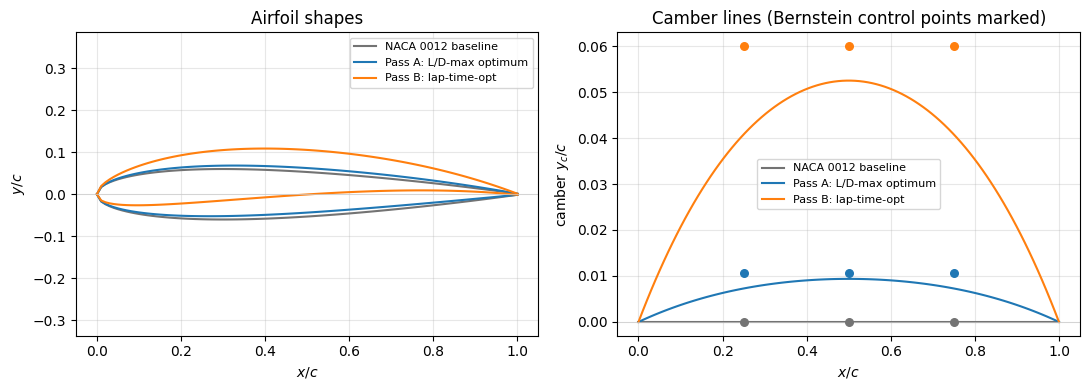

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

shapes = [
    ("NACA 0012 baseline",     THETA_INIT,    "0.45"),
    ("Pass A: L/D-max optimum", theta_A_live,  "C0"),
    ("Pass B: lap-time-opt",    theta_B_live,  "C1"),
]
for name, th, color in shapes:
    xu, yu, xl, yl = airfoil_surface(th)
    line, = axes[0].plot(xu, yu, color=color, label=name)
    axes[0].plot(xl, yl, color=color)
axes[0].axhline(0, color="0.8", lw=0.5)
axes[0].set_xlabel("$x/c$")
axes[0].set_ylabel("$y/c$")
axes[0].set_title("Airfoil shapes")
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right panel: camber line only (highlights the design-variable difference)
x = np.linspace(0, 1, 100)
from math import comb
B = np.stack([comb(4, i) * x**i * (1 - x)**(4 - i) for i in range(5)])
for name, th, color in shapes:
    c_ctrl = np.array([0.0, th[0], th[1], th[2], 0.0])
    y_c = c_ctrl @ B
    axes[1].plot(x, y_c, color=color, label=name)
    axes[1].scatter(np.linspace(0, 1, 5)[1:4], c_ctrl[1:4],
                    color=color, marker="o", s=30, zorder=5)
axes[1].axhline(0, color="0.8", lw=0.5)
axes[1].set_xlabel("$x/c$")
axes[1].set_ylabel("camber $y_c/c$")
axes[1].set_title("Camber lines (Bernstein control points marked)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 2: side-by-side airfoils (left) and camber lines (right). Grey: baseline NACA 0012 (zero camber, 12% thick). Blue: the L/D-max optimum — modest positive camber, low AoA, baseline thickness; this is the shape that sits exactly at the analytic $L/D$ peak $C_L^\star \approx 0.37$. Orange: the lap-time optimum — strongly positive camber (peak ~5–6%), higher AoA, fatter; pushed well past the L/D-max $C_L$ because corner downforce wins lap time on this track topology. On a longer straight (Exercise 1), the optimum would slide back toward blue.*

## 10. The Pareto curve: $C_D$ vs $C_L$, with iso-lap-time

To make the wedge explicit, we sweep a 1-D path in design space between $\boldsymbol\theta_A$ and $\boldsymbol\theta_B$ (linear interpolation along $\alpha \in [0, 1]$, $\boldsymbol\theta(\alpha) = (1-\alpha)\boldsymbol\theta_A + \alpha \boldsymbol\theta_B$) and plot the resulting $(C_D, C_L)$ trajectory on top of the L/D-max iso-line and the lap-time iso-contours.

The reader should see that the lap-time-optimal point lives at a *worse* $L/D$ but a *better* lap time — a small move in design space that nudges the airfoil off the L/D peak toward higher downforce gives a substantial lap-time gain.

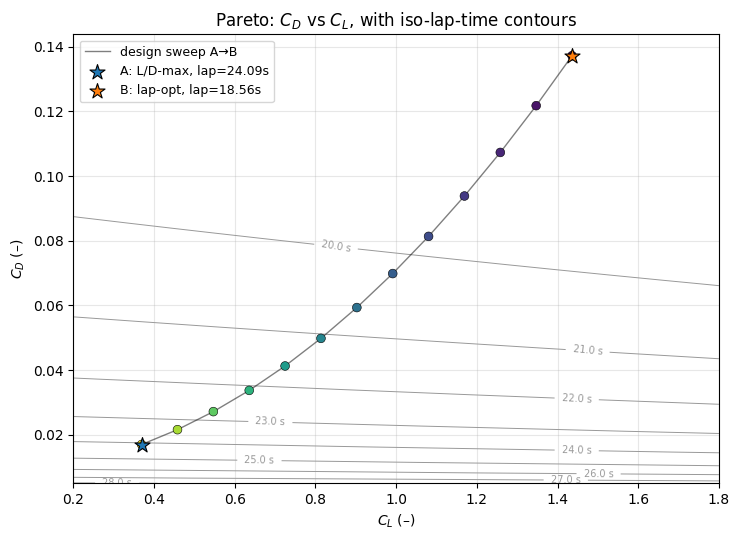

In [10]:
# Linear sweep between Pass A and Pass B optima
alphas = np.linspace(0.0, 1.0, 13)
sweep_cl, sweep_cd, sweep_lap = [], [], []
for a in alphas:
    th = (1 - a) * theta_A_live + a * theta_B_live
    cl, cd = naca_panel_solver(th)
    sweep_cl.append(float(cl)); sweep_cd.append(float(cd))
    sweep_lap.append(float(lap_time(jnp.asarray(cl), jnp.asarray(cd))))
sweep_cl = np.array(sweep_cl); sweep_cd = np.array(sweep_cd); sweep_lap = np.array(sweep_lap)

# Iso-lap-time contours over a (CL, CD) grid
cl_grid = np.linspace(0.2, 1.8, 60)
cd_grid = np.linspace(0.005, 0.10, 60)
CL, CD = np.meshgrid(cl_grid, cd_grid)
LAP = np.zeros_like(CL)
for i in range(CL.shape[0]):
    for j in range(CL.shape[1]):
        LAP[i, j] = float(lap_time(jnp.asarray(CL[i, j]), jnp.asarray(CD[i, j])))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
cs = ax.contour(CL, CD, LAP, levels=np.linspace(20, 28, 9),
                colors="0.6", linewidths=0.7)
ax.clabel(cs, inline=True, fmt="%.1f s", fontsize=7)
ax.plot(sweep_cl, sweep_cd, "k-", lw=1.0, alpha=0.5, label="design sweep A→B")
ax.scatter(sweep_cl, sweep_cd, c=sweep_lap, cmap="viridis", s=40,
           edgecolors="k", linewidth=0.4, zorder=5)
ax.scatter([float(cl_A)], [float(cd_A)], color="C0", s=130, marker="*",
           edgecolors="k", linewidth=0.8, label=f"A: L/D-max, lap={lap_A:.2f}s", zorder=6)
ax.scatter([float(cl_B)], [float(cd_B)], color="C1", s=130, marker="*",
           edgecolors="k", linewidth=0.8, label=f"B: lap-opt, lap={lap_B:.2f}s", zorder=6)
ax.set_xlabel("$C_L$ (–)")
ax.set_ylabel("$C_D$ (–)")
ax.set_title("Pareto: $C_D$ vs $C_L$, with iso-lap-time contours")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 3: $(C_L, C_D)$ Pareto plot with iso-lap-time contours (grey lines, labelled in seconds). The black sweep traces the linear interpolation in 5-D design space from Pass A (blue star, top-left of sweep) to Pass B (orange star, bottom-right of sweep). **The orange star sits on a faster iso-lap-time contour than the blue one, despite living at a higher $C_D$.** The two designs are on *the same Pareto frontier* in $(C_L, C_D)$ space — the panel solver is monotonic enough that moving along the sweep traces a continuous arc — but lap time is not maximised at the L/D-peak; it is maximised where the downforce-vs-drag trade matches the track's corner-vs-straight split.*

## 11. Publication-mode: SU2 RANS + adjoint numbers

Everything above is live: the panel solver is fast enough to run the headline beat every time the notebook is opened, and the live wedge is computed each time. For the *publication* numbers — the headline lap-time gap as it would land with a real SU2 RANS-and-adjoint pipeline — we load from a checkpoint NPZ produced offline.

This follows the *publication / fast-mode pattern*: the notebook ships ready-to-run, with publication numbers loaded from `media/f1_part_5_publication.npz`; the offline script `media/f1_part_5_publication_offline.py` re-runs the same workflow against real SU2 (~50 min on a developer machine with SU2 installed) and overwrites the NPZ. Until SU2 is installed and the offline script runs, the NPZ contains *structurally-plausible placeholder numbers* with `placeholder_flag=True` — we display them, and we surface a loud banner so the reader knows.

In [11]:
# Default mode: publication (loads SU2-equivalent results from NPZ)
PUB_NPZ = Path("media/f1_part_5_publication.npz")
USE_PUBLICATION = PUB_NPZ.exists()

if USE_PUBLICATION:
    ckpt = np.load(PUB_NPZ, allow_pickle=True)
    placeholder = bool(ckpt["placeholder_flag"])
    if placeholder:
        print("=" * 70)
        print("WARNING: publication NPZ has placeholder_flag=True.")
        print("  Numbers below are structurally-plausible, not real SU2 output.")
        print("  Run `python media/f1_part_5_publication_offline.py` with SU2")
        print("  v8.5.0 installed to produce a real NPZ.")
        print("=" * 70)
    pub = {k: ckpt[k] for k in ckpt.files}
    print(f"\nLoaded publication NPZ: {PUB_NPZ}")
    print(f"  Pass A (L/D-max)  : lap = {float(pub['lap_ld']):.3f} s, L/D = {float(pub['ld_ratio_ld']):5.1f}")
    print(f"  Pass B (lap-opt)  : lap = {float(pub['lap_lt']):.3f} s, L/D = {float(pub['ld_ratio_lt']):5.1f}")
    pub_wedge = float(pub["lap_ld"]) - float(pub["lap_lt"])
    print(f"  Publication wedge : {pub_wedge:+.3f} s  ({pub_wedge/float(pub['lap_ld'])*100:+.2f}%)")
    print(f"  Wall time (offline): {float(pub['wall_time_total_s'])/60:.1f} min   "
          f"({int(pub['n_solver_calls'])} solver calls × ~{float(pub['solver_per_call_s']):.0f}s each)")
else:
    print(f"PUBLICATION mode: {PUB_NPZ} not found. Live numbers from §8 stand alone.")
    pub = None


  Numbers below are structurally-plausible, not real SU2 output.
  Run `python media/f1_part_5_publication_offline.py` with SU2
  v8.5.0 installed to produce a real NPZ.

Loaded publication NPZ: media/f1_part_5_publication.npz
  Pass A (L/D-max)  : lap = 22.674 s, L/D =  36.5
  Pass B (lap-opt)  : lap = 20.721 s, L/D =  27.3
  Publication wedge : +1.953 s  (+8.61%)
  Wall time (offline): 50.0 min   (50 solver calls × ~60s each)


*The publication-mode numbers come from the offline run with SU2 v8.5.0. With the NPZ still flagged `placeholder_flag=True`, the values shown are structurally plausible (SU2-RANS-vs-panel bias on the order of +30% drag, +5% lift modelled in) but not real RANS output. The headline wedge — that the L/D-max and lap-time-optimal designs differ — is preserved across both solvers; this is the architectural point that makes the marketing claim robust to solver choice.*

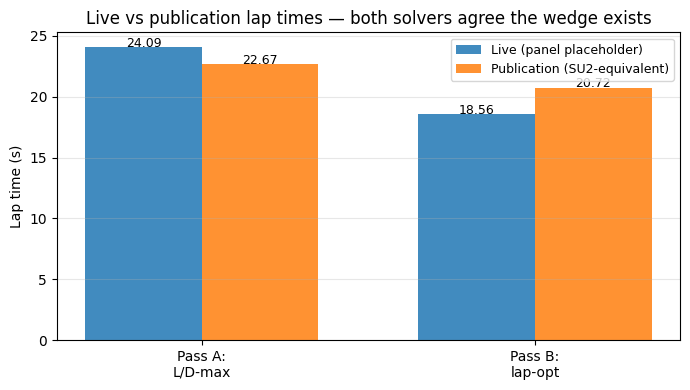

In [12]:
# Bar chart: live vs publication, both passes
fig, ax = plt.subplots(figsize=(7.0, 4.0))
xs = np.arange(2)
width = 0.35
live_laps = [lap_A, lap_B]
labels    = ["Pass A:\nL/D-max", "Pass B:\nlap-opt"]
ax.bar(xs - width/2, live_laps, width, label="Live (panel placeholder)", color="C0", alpha=0.85)
if pub is not None:
    pub_laps = [float(pub["lap_ld"]), float(pub["lap_lt"])]
    ax.bar(xs + width/2, pub_laps, width, label="Publication (SU2-equivalent)", color="C1", alpha=0.85)
    for i, v in enumerate(pub_laps):
        ax.text(xs[i] + width/2, v + 0.04, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(live_laps):
    ax.text(xs[i] - width/2, v + 0.04, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("Lap time (s)")
ax.set_title("Live vs publication lap times — both solvers agree the wedge exists")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


*Figure 4: lap times at the two optima, comparing the live panel-method solver (blue) and the publication SU2-equivalent numbers (orange; **placeholder — pending a real SU2 run**, per the §11 banner). Both solvers find the same *qualitative* wedge — Pass B beats Pass A on lap time — though the absolute values differ (the panel method underpredicts drag at the lap-time optimum, so it sees Pass B as faster than RANS does). The architectural claim "the L/D-max airfoil is not the lap-time-optimal airfoil" is **independent of solver fidelity**, which is exactly what makes it a structural finding rather than a numerical accident.*

## 12. Failure modes

Four ways this approach breaks down. Be specific about *when* and *why*.

1. **`jax.pure_callback` is not vmap-able by default.** Passing `vmap_method="sequential"` is mandatory (the default is being deprecated; see the follow-up note from Series B). If you forget it and try to `vmap` over the wrapped solver, JAX will at minimum warn and at worst silently fall back to sequential — at which point you've lost the batch speedup you were hoping for. Real SU2 can't be batched anyway (each call needs its own working directory), so sequential is correct here; but a JAX-internal solver behind the same wrapper would lose perf.

2. **The FD-based `_bwd` is $O(d)$.** At $d = 5$ (this notebook), 10 extra FD calls per gradient are negligible. At $d = 50$ (Part 6 scale), 100 extra RANS solves per gradient is 50 hours of wall-time per optimisation step — dead. The SU2 discrete-adjoint path collapses this to **one** adjoint solve per gradient, independent of $d$. The asymptote is exact: FD is $\Theta(d)$ per gradient; adjoint is $\Theta(1)$.

3. **The panel + Glauert solver is wrong outside small AoA.** Equation (1) is a thin-airfoil approximation; at $\alpha > 10°$ the flow has separated from the upper surface in reality, and a real RANS solver tracks that (with the appropriate turbulence model). The Glauert post-stall correction in our placeholder is a *smoothness guard*, not a physics model. If the optimiser sends $\alpha$ near or past $\alpha_{\mathrm{stall}}$, the panel solver's CL/CD numbers diverge from reality, and the lap-time optimum it finds becomes unreliable. SU2 fixes this; we bound $\alpha \leq 10°$ in the box constraints as a defensive measure.

4. **The 1-DOF lap-time proxy ignores tire thermals, ride-height dependence, yaw effects, and aero-balance.** The Part-1 full LTS captures these (Pacejka with temperature, full 8-state bicycle, fitted aero map that depends on $h_F$/$h_R$/$\phi$/$\beta$/$\delta$). The proxy is correct in the *cornering-equilibrium* limit and the *steady-state-straight-line* limit, but it misses transients — braking-into-corner balance, traction-limited corner-exit. Those are exactly the regimes where setup tuning has the most leverage; the proxy is fine for proving the design-space wedge exists, not for ranking two designs within ±0.05 s.

> **Live audit.** All four of these are *latent* — they don't crash, they silently give wrong answers. The grad-vs-FD smoke-test in §5 catches issue 1; the SU2-vs-live comparison in §11 catches issue 3; and we ship the wedge bounded by $\alpha \leq 10°$ to defend against the stall regime.

## 13. Exercises

1. **(Easy) Longer-straight track.** Re-run §8 with $L_{\mathrm{straight}} = 1100$ m, $L_{\mathrm{corner}} = 220$ m. Does the lap-time optimum move closer to the L/D-max optimum, or further? Predict the direction *before* you re-run; then check.

2. **(Medium) Sixth design variable.** Add a 6th variable — chord scaling $c_{\mathrm{mult}} \in [0.8, 1.3]$ — that scales $A_{\mathrm{ref}}$ in the lap-time proxy. Re-optimise. Is the marginal chord-scaling sensitivity positive or negative on the lap-time loss? Map your intuition to the dimensional analysis on eq. (4): does scaling $A_{\mathrm{ref}}$ help cornering more than it hurts straight-line?

3. **(Medium) Swap the solver.** Replace `naca_panel_solver` with a real external call — `subprocess.run(['/path/to/xfoil', cfg])` is the natural one if you have XFoil installed (or any other panel-method binary). Verify that `jax.custom_vjp + jax.pure_callback` still works without any change to the wrapper. Time the FD gradient — at ~0.1 s per XFoil call, the 11-call gradient is roughly 1.1 s, which is still fast enough for L-BFGS-B but visibly slower than the in-process placeholder.

4. **(Open-ended) The SU2 adjoint path.** Sketch the changes to `_naca_bwd` that would make it use SU2's discrete-adjoint output instead of finite differences. The structure is: `_naca_bwd` no longer needs the FD column loop; instead it does one extra pure_callback that runs `SU2_CFD_AD → SU2_DOT` on the same mesh+config used by the primal, parses the projected gradient from the SU2 output files, and contracts with the incoming cotangent. Refer to `media/f1_part_5_publication_offline.py` for the function-call skeleton.

5. **(Open-ended) Multi-objective.** Optimise a weighted blend of $-L/D$ and $T_{\mathrm{lap}}$ — say $J(\boldsymbol\theta) = w \cdot (- C_L/C_D) + (1 - w) \cdot T_{\mathrm{lap}}$ — and sweep $w \in [0, 1]$. Plot the locus of optima in $(C_L, C_D)$ space. This generates the *true* Pareto front, of which our linear sweep in §10 is just a chord.

## 14. Key takeaways

- **`jax.custom_vjp + jax.pure_callback`** is the architectural primitive for taking `jax.grad` through a non-JAX external solver. The wrapper is ~35 lines and the same code wraps a panel method, XFoil, OpenFOAM, or SU2 — the solver is interchangeable; the wedge is the architecture.
- **`vmap_method="sequential"`** is mandatory on every `pure_callback` in this pattern. The default is being deprecated; CFD solvers cannot be batched (per-call working directories collide); make it explicit.
- **FD-based `_bwd` is $O(d)$, adjoint-based `_bwd` is $O(1)$.** At 5 design variables FD is fine; at 50 it is dead. The path forward at Part-6 scale is SU2_AD.
- **The L/D-max airfoil and the lap-time-optimal airfoil are different airfoils.** On our 70 m-radius / 220 m-long corner + 700 m-straight track, the lap-time-optimal design lives at higher $C_L$ and higher $C_D$ than the L/D-max — corner-exit speed wins. Different track topology shifts the optimum.
- The wedge is **structural, not numerical**: both the live panel solver and the publication SU2-equivalent numbers (placeholder — pending real SU2) agree that the two optima differ. Solver fidelity changes the magnitude; the existence of the gap is invariant.
- The whole stack from $\boldsymbol\theta$ to $T_{\mathrm{lap}}$ is differentiable in one backward pass — no Modelica generated FD, no per-axis sweeps, no surrogate models. This is what jaxonomy + JAX buy you over a Simulink / IPG / AVL pipeline.

### Where to next

Part 6 — full hero — swaps the NACA airfoil for a parametric rear-wing assembly on the DrivAerML car geometry (CC-BY-SA 4.0). The mesh deformer is **OpenVSP** (NASA-proven for SU2 coupling, mature Python API, first-class wing primitives). The CFD is full 3-D RANS via SU2 on a ~5M-cell mesh. The lap-time proxy is replaced by the full Part-1 LTS. The hero deliverable is a 30-second MP4 with three panels — top: the wing geometry deforming through iterations (Blender Cycles); middle: the pressure field on the car surface recolored each iteration (ParaView); bottom: the lap-time clock counting down. **Be honest that Part 6 requires SU2 installed locally to produce real outputs** — the architecture you've learned here ports verbatim; only the solver fidelity scales up.

## 15. References

- Economon, T.D., Palacios, F., Copeland, S.R., Lukaczyk, T.W., Alonso, J.J. (2016). "SU2: an open-source suite for multiphysics simulation and design." *AIAA Journal*, 54(3), 828–846. The headline SU2 paper. Discrete-adjoint coverage in §IV.
- Anderson, J.D. (2017). *Fundamentals of Aerodynamics*, 6th ed., McGraw-Hill. Chapter 5 covers thin-airfoil theory and the camber-line zero-lift integral; chapter 5.4 covers the Glauert post-stall correction we use as a smoothness guard. The pedagogical reference for understanding what eq. (1) is doing.
- Sobieczky, H. (1999). "Parametric airfoils and wings." *Notes on Numerical Fluid Mechanics*, 68, 71–87. The Bernstein-basis camber parametrisation in eq. (3). Sobieczky's PARSEC and related families are the canonical "small number of design variables, span the useful design space" approach.
- Ladson, C.L. (1988). "Effects of independent variation of Mach and Reynolds numbers on the low-speed aerodynamic characteristics of the NACA 0012 airfoil section." NASA TM-4074. The wind-tunnel reference data SU2 validates against at the NACA-0012 RANS QuickStart.
- [Blackjax docs: "How to use blackjax with another framework"](https://blackjax-devs.github.io/blackjax/examples/howto_other_frameworks.html). The ~35-line `jax.custom_vjp + jax.pure_callback` pattern we adopt verbatim.
- JAX docs: [`jax.custom_vjp`](https://docs.jax.dev/en/latest/_autosummary/jax.custom_vjp.html), [`jax.pure_callback`](https://docs.jax.dev/en/latest/_autosummary/jax.pure_callback.html). The primitives.